In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
import joblib
import os
import sys
import random
from getpass import getpass
from tqdm import tqdm

#### I. Configurations

###### 1. Desmontar

###### sudo umount -l /home/guiomar/carpeta_servidor

###### 2. Montar
###### mkdir -p ~/carpeta_servidor
###### sshfs sade06cy@zuse.math.uni-magdeburg.de:/home/sade06cy/predicting-flow-patterns/New_Experiment ~/carpeta_servidor

###### 3. Vincular
###### sudo ln -sf ~/carpeta_servidor/config.yaml /home/sade06cy/predicting-flow-patterns/New_Experiment/config.

###### 4. Vincular subcarpeta
###### sudo ln -sfn ~/carpeta_servidor/Results_training /home/sade06cy/predicting-flow-patterns/New_Experiment/Results_training

In [2]:
path = os.path.expanduser("~/carpeta_servidor")
print("Archivos encontrados:", os.listdir(path))

Archivos encontrados: ['unet_MLP.py', 'train_model.py', 'Forces.csv', 'evaluate.py', 'geometry', 'dataset_index.csv', 'u_net_architecture.py', 'test_train.txt', 'config.yaml', 'vgg.py', 'P_Masked.tar.gz', 'Results_training', 'csv_final.csv', 'val.csv', '__pycache__', 'Forces_ID.csv', 'processvtk.py', 'P_Masked', 'U_Net_Bifurcada.py', 'utils.py', 'config_mod.yaml', 'train.csv', 'Results', 'test.csv', 'dataset.py', 'config.py', 'g.tar.gz', 'Vy_Masked.tar.gz', 'File_times.csv', 'Vx_Masked', 'Vx_Masked.tar.gz', 'dataset_master.csv', 'V_Masked', 'Vy_Masked', 'get_data.ipynb', 'test_train.ipynb']


In [ ]:
ruta_proyecto = os.path.expanduser("~/carpeta_servidor")

if ruta_proyecto not in sys.path:
    sys.path.insert(0, ruta_proyecto)

%load_ext autoreload
%autoreload 2

#### II. Load Model and Data

In [133]:
from u_net_architecture import *
from dataset import load_dataset,DataGenerator
from config import load_config


In [134]:
weights='/home/guiomar/Desktop/CODES/predicting-flow-patterns/Nuevo_experimento/U_net_Mlp/U_net_Mlp_best.weights.h5'
scaler_path='/home/guiomar/Desktop/CODES/predicting-flow-patterns/Nuevo_experimento/scaler_targets.pkl'
test_values='/home/guiomar/Desktop/CODES/predicting-flow-patterns/Nuevo_experimento/test_old.csv'

In [135]:
def load_model():
    model = unet_mlp_make_model()
    model.load_weights(weights)
    scaler = joblib.load(scaler_path)
    return model, scaler

def load_data():
    '''
    'flow_output':Y, where Y=[velocity,velocity_x,velocity_y,pressure]
    'drag_1': d1,
    'lift_1':l1,
    'drag_2':d2,
    'lift_2':l2
    '''
    
    _,_,test = load_dataset() # seed 42
    aleatory_sample = random.randint(0, len(test))

    geometry,ytrue=test[aleatory_sample]

    print(f'Batch number: {aleatory_sample}/{len(test)}')

    velocity=[]
    velocity_x=[]
    velocity_y=[]
    pressure=[]
    d1=[]
    d2=[]
    l1=[]
    l2=[]
  
    for i in tqdm(range(len(geometry)), desc="Processed"):
        velocity.append(ytrue['flow_output'][i,:,:,0])
        velocity_x.append(ytrue['flow_output'][i,:,:,1])
        velocity_y.append(ytrue['flow_output'][i,:,:,2])
        pressure.append(ytrue['flow_output'][i,:,:,3])
        d1.append(ytrue['drag_1'][i])
        d2.append(ytrue['drag_2'][i])
        l1.append(ytrue['lift_1'][i])
        l2.append(ytrue['lift_2'][i])

    return aleatory_sample ,geometry, velocity, velocity_x, velocity_y, pressure, d1, d2, l1, l2

#### III. Predictions

In [ ]:
'''
y_pred: 5 elements list
- y_pred[0]: tensor (10,64,256,4)
- y_pred[1]: tensor (10,1)--> d1
- y_pred[2]: tensor (10,1)--> l1
- y_pred[3]: tensor (10,1)--> d2
- y_pred[4]: tensor (10,1)--> l2
'''
model, scaler = load_model()
number,geometry, velocity, velocity_x, velocity_y, pressure, d1, d2, l1, l2=load_data()
y_pred = model.predict(geometry, verbose=0)
forces = np.hstack([y_pred[1], y_pred[2], y_pred[3], y_pred[4]])
# Desnormalization
forces_true = scaler.inverse_transform(forces) # Shape(10,4)
d1_final = forces_true[:, 0]
l1_final = forces_true[:, 1]
d2_final = forces_true[:, 2]
l2_final = forces_true[:, 3]

/home/guiomar/micromamba/envs/My_Env/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.1 when using version 1.5.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Batch number: 26/37


Processed: 100%|██████████| 10/10 [00:00<00:00, 40098.51it/s]


##### III.1 Flow

Example  0/10


Generating Plots: 100%|██████████| 4/4 [00:00<00:00, 1746.35it/s]


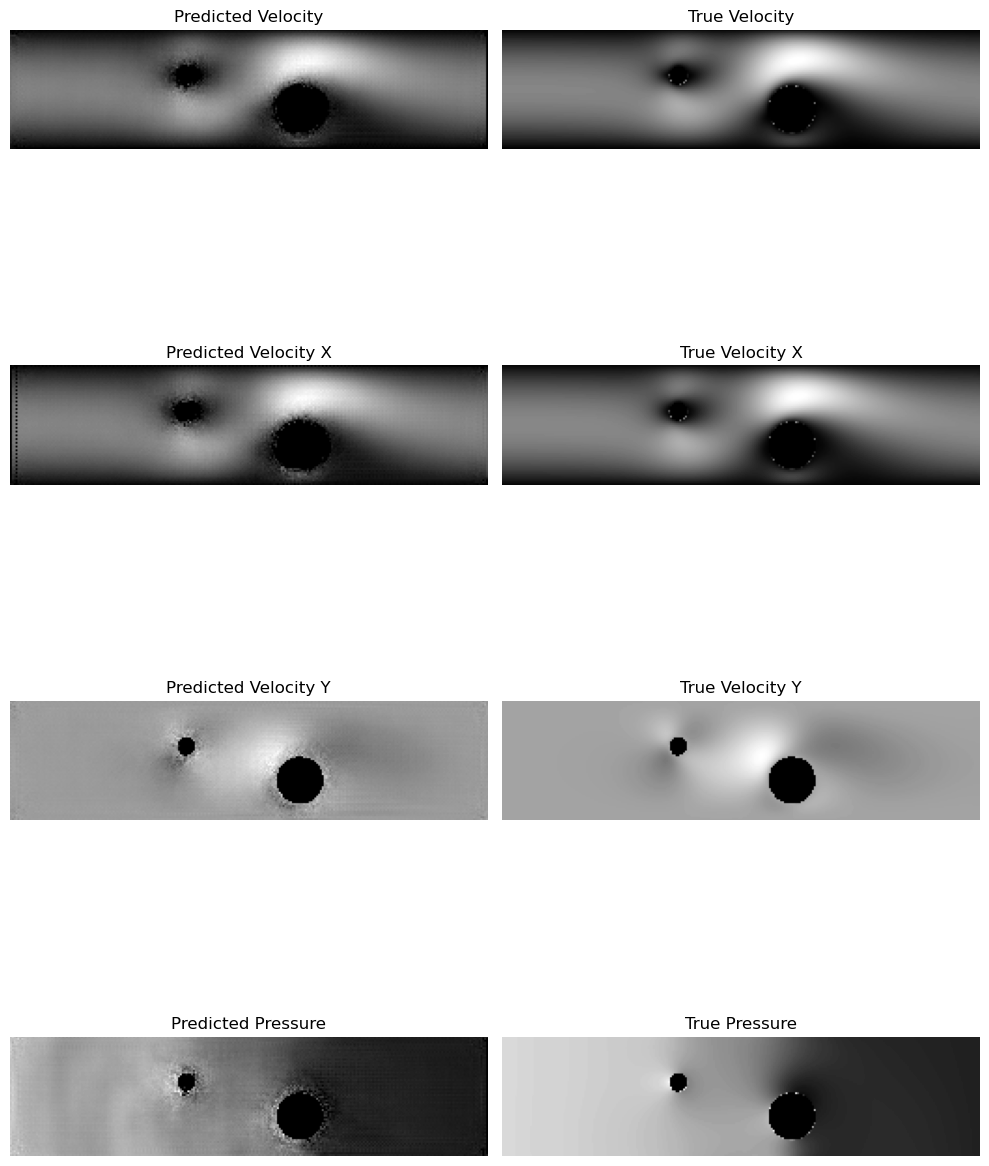

In [137]:
sample = random.randint(0, 10)
titles={0: ['Predicted Velocity','True Velocity'], 1: ['Predicted Velocity X','True Velocity X'], 2: ['Predicted Velocity Y','True Velocity Y'], 3: ['Predicted Pressure','True Pressure']}
fig, axes = plt.subplots(4, 2, figsize=(10, 15))
true_imgs = [velocity[sample], velocity_x[sample], velocity_y[sample], pressure[sample]]
print(f'Example  {sample}/10')
for i in tqdm(range(4), desc="Generating Plots"):
    # --- Column 0  Predicted ---
    
    axes[i, 0].imshow(y_pred[0][sample,:,:,i], cmap='gray')
    axes[i, 0].set_title(titles[i][0])
    axes[i, 0].axis('off')

    # --- Column 1: True ---

    img_real=true_imgs[i]
    axes[i, 1].imshow(img_real, cmap='gray')
    axes[i, 1].set_title(titles[i][1])
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()


#### III.2 Forces

In [146]:
def plot_curve(drag_true,lift_true,drag_pred,lift_pred,n_cilinder):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

    # --- Plot 1: DRAG (Resistencia) ---
    ax1.plot(drag_true.values, label='Drag Real', color='blue', marker='o',linewidth=2)
    ax1.plot(list(drag_pred), label='Drag Predicho', color='red', linestyle='--', marker='x', markersize=4)
    ax1.set_ylabel('Coeficiente de Drag ($C_d$)')
    ax1.set_title(f'Cilindro {n_cilinder}: Drag Real vs Predicho')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- Plot 2: LIFT (Sustentación) ---
    ax2.plot(lift_true.values, label='Lift Real', color='blue', marker='o', linewidth=2)
    ax2.plot(list(lift_pred), label='Lift Predicho', color='red', linestyle='--', marker='x', markersize=4)
    ax2.set_ylabel('Coeficiente de Lift ($C_l$)')
    ax2.set_title(f'Cilindro {n_cilinder}: Lift Real vs Predicho')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_scatter(drag_true,lift_true,drag_pred,lift_pred,n_cilinder):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # --- Scatter Plot: DRAG ---
    ax1.scatter(drag_true.values,drag_true.values, color='blue', label='Real', s=50)
    ax1.scatter(drag_true.values,drag_pred, color='red', label='Predicción', s=50)
    lims = [np.min([ax1.get_xlim(), ax1.get_ylim()]), np.max([ax1.get_xlim(), ax1.get_ylim()])]
    ax1.plot(lims, lims, 'g--', alpha=0.75, zorder=0, label='Ideal ($y=x$)')
    ax1.set_title(f'Cilindro {n_cilinder}: Correlation Drag ($C_d$)')
    ax1.set_xlabel('Real')
    ax1.set_ylabel('Pred')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- Scatter Plot: LIFT ---
    ax2.scatter(lift_true.values, lift_true.values, color='blue', label='Real', s=50)
    ax2.scatter(lift_true.values, lift_pred, color='red', label='Predicción', s=50)
    lims_l = [np.min([ax2.get_xlim(), ax2.get_ylim()]), np.max([ax2.get_xlim(), ax2.get_ylim()])]
    ax2.plot(lims_l, lims_l, 'g--', alpha=0.75, zorder=0, label='Ideal ($y=x$)')
    ax2.set_title(f'Cilindro {n_cilinder}: Correlation Lift ($C_l$)')
    ax2.set_xlabel('Real')
    ax2.set_ylabel('Pred')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def absolute_error(batch, d_name,l_name,d_pred,l_pred,n_cylinder):
    drag_real = batch[d_name]
    drag_pred = list(d_pred)

    lift_real = batch[l_name]
    lift_pred = list(l_pred)
    indices = list(batch.index)

    # Calculamos el Error Absoluto
    error_drag = np.abs(drag_real - drag_pred)
    error_lift = np.abs(lift_real - lift_pred)

    plt.figure(figsize=(12, 6))

    # Subplot 1: Error en Drag
    plt.subplot(1, 2, 1)
    plt.bar(indices, error_drag, color='skyblue', edgecolor='navy')
    plt.title(f'Cylinder {n_cylinder} - Error Absoluto - Drag Force')
    plt.xlabel('ID')
    plt.ylabel('Error |Real - Pred|')
    plt.xticks(indices)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Subplot 2: Error en Lift
    plt.subplot(1, 2, 2)
    plt.bar(indices, error_lift, color='salmon', edgecolor='darkred')
    plt.title(f'Cylinder {n_cylinder} - Error Absoluto - Lift Force')
    plt.xlabel('ID')
    plt.ylabel('Error |Real - Pred|')
    plt.xticks(indices)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()


def get_metrics(drag_true, lift_true, drag_pred, lift_pred, n_cylinder):
        metrics = {
            "MAE_Drag": mean_absolute_error(drag_true, drag_pred),
            "MAE_Lift": mean_absolute_error(lift_true, lift_pred),
            "MSE_Drag": mean_squared_error(drag_true, drag_pred),
            "MSE_Lift": mean_squared_error(lift_true, lift_pred),
            "R2_Drag": r2_score(drag_true, drag_pred),
            "R2_Lift": r2_score(lift_true, lift_pred)
        }
        print("=== Evaluation metrics===")
        print(f'===== Cylinder {n_cylinder} =====')

        print(f"Drag_{n_cylinder} -> MSE: {metrics['MSE_Drag']:.4f}, MAE: {metrics['MAE_Drag']:.4f}, R2: {metrics['R2_Drag']:.4f}")
        print(f"Lift_{n_cylinder} -> MSE: {metrics['MSE_Lift']:.4f}, MAE: {metrics['MAE_Lift']:.4f}, R2: {metrics['R2_Lift']:.4f}")

        mape_drag = np.mean(np.abs((drag_true - drag_pred) / drag_true)) * 100
        print(f"Percentage error Drag_{n_cylinder}: {mape_drag:.2f}%")

        mape_lift = np.mean(np.abs((lift_true - lift_pred) / lift_true)) * 100
        print(f"Percentage error Lift_{n_cylinder}: {mape_lift:.2f}%\n")
        return metrics["MAE_Drag"], metrics["MAE_Lift"]


In [139]:
df = pd.read_csv(test_values) 
batch_size=10
for i, j in enumerate(range(0, len(df), batch_size)):
   if i==number:
      batch = df[['Drag_1', 'Lift_1', 'Drag_2', 'Lift_2']][j:j + batch_size]
print('Real Values regarding to batch number:', number)      
batch


Real Values regarding to batch number: 26


,Drag_1,Lift_1,Drag_2,Lift_2
260,333.607,-25.1045,929.172,376.4700
261,740.038,152.6530,1631.110,248.0270
262,675.342,38.0473,292.634,-42.5583
263,740.977,204.1900,478.593,75.4566
264,1147.320,200.5190,1012.400,-179.9720
265,960.786,36.5944,1193.730,351.4400
266,771.660,-42.2849,929.678,199.3330
267,329.179,-71.6958,366.260,-40.4824
268,907.523,-109.6090,450.359,175.0490
269,865.792,-226.8650,349.723,10.7046


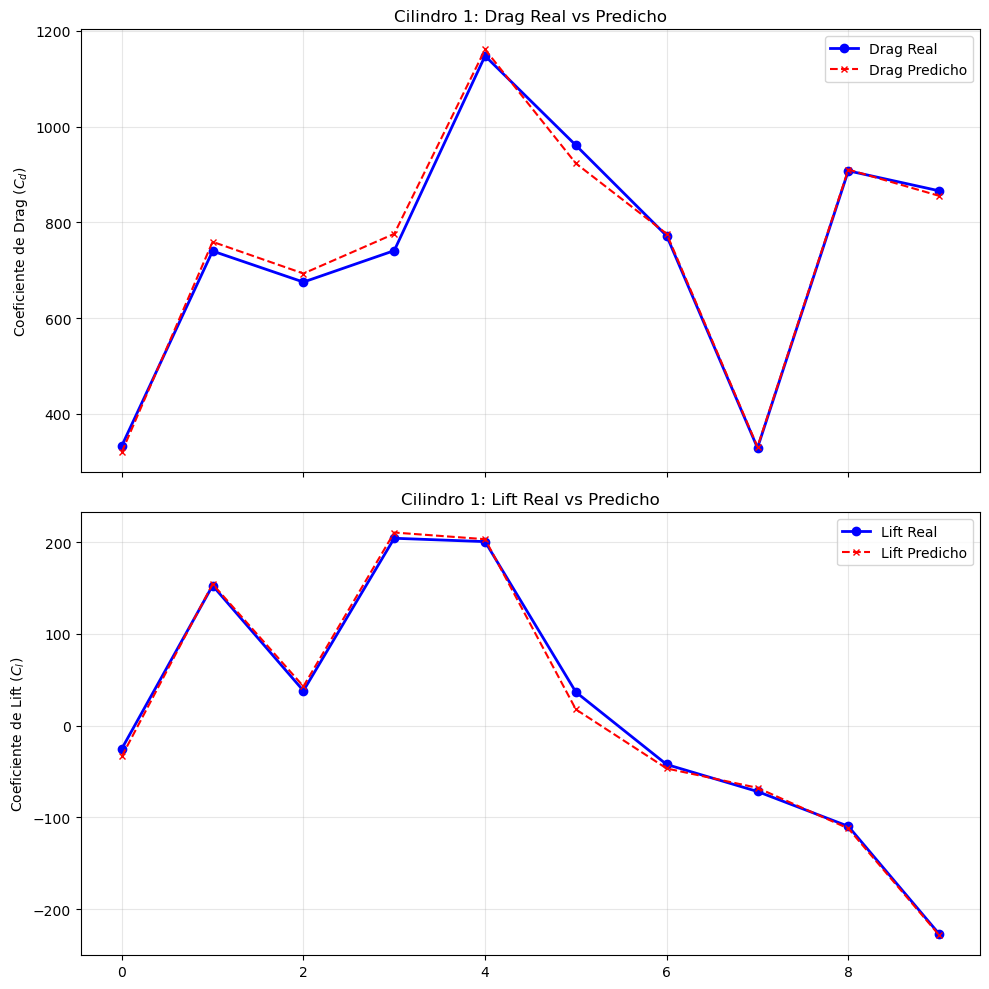

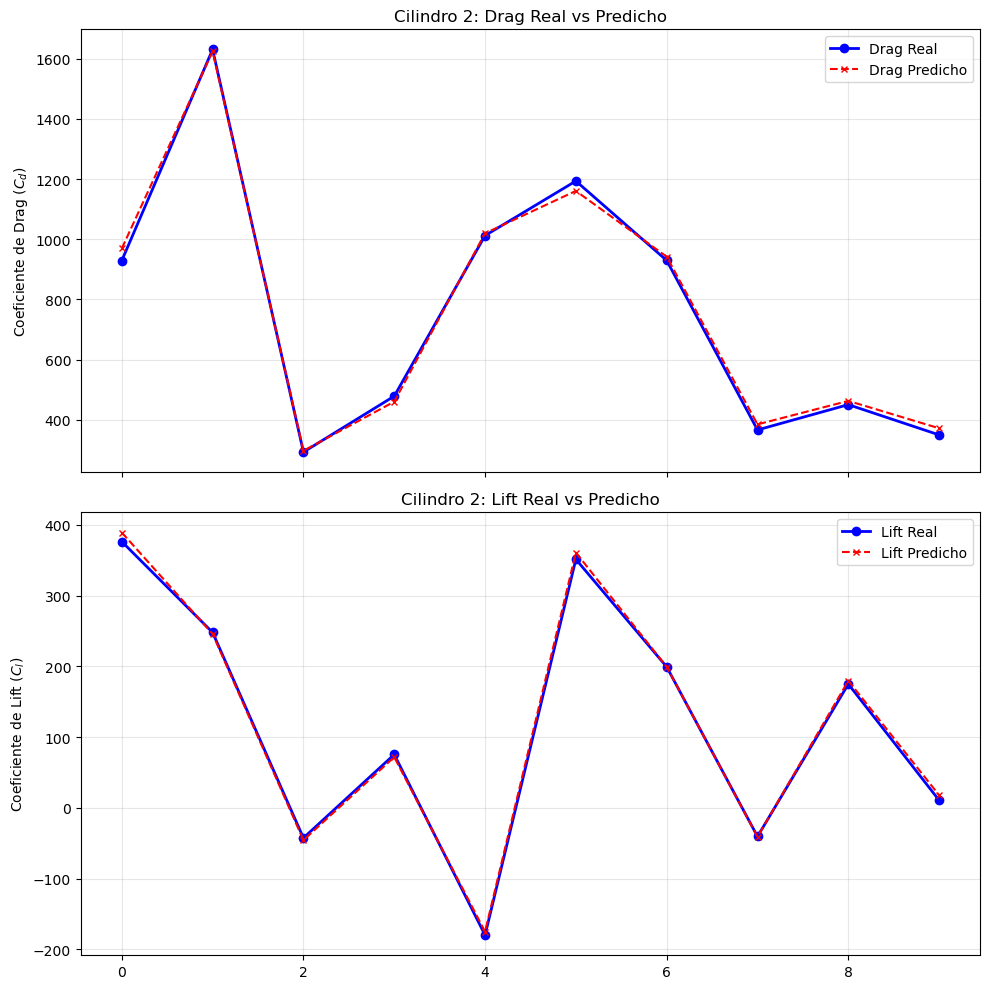

In [140]:
plot_curve(batch['Drag_1'], batch['Lift_1'], d1_final, l1_final, 1)
plot_curve(batch['Drag_2'], batch['Lift_2'], d2_final, l2_final, 2)


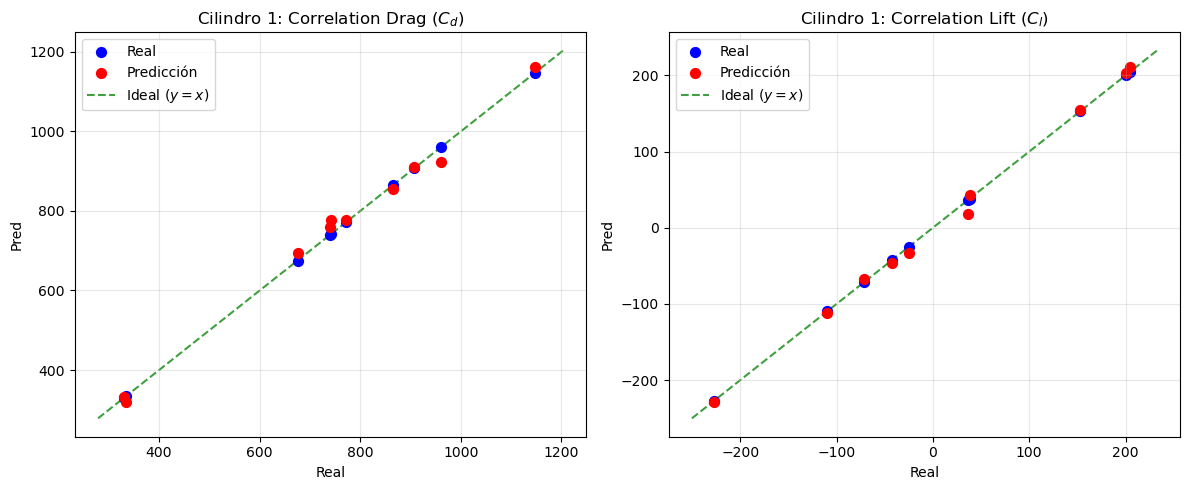

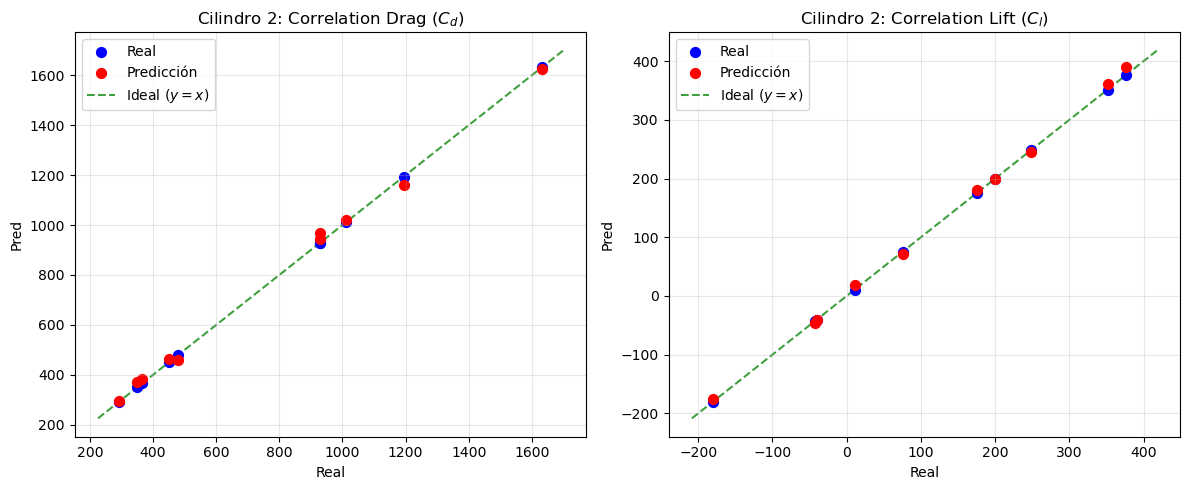

In [147]:
plot_scatter(batch['Drag_1'], batch['Lift_1'], d1_final, l1_final, 1)
plot_scatter(batch['Drag_2'], batch['Lift_2'], d2_final, l2_final, 2)


In [142]:
mae_d1, mae_l1 = get_metrics(batch['Drag_1'], batch['Lift_1'], d1_final, l1_final, 1)
mae_d2, mae_l2 = get_metrics(batch['Drag_2'], batch['Lift_2'], d2_final, l2_final, 2)

=== Evaluation metrics===
===== Cylinder 1 =====
Drag_1 -> MSE: 384.1112, MAE: 15.6302, R2: 0.9936
Lift_1 -> MSE: 53.7964, MAE: 5.4453, R2: 0.9970
Percentage error Drag_1: 2.18%
Percentage error Lift_1: 12.11%

=== Evaluation metrics===
===== Cylinder 2 =====
Drag_2 -> MSE: 430.3680, MAE: 17.5554, R2: 0.9976
Lift_2 -> MSE: 37.9595, MAE: 4.8449, R2: 0.9987
Percentage error Drag_2: 2.90%
Percentage error Lift_2: 9.29%



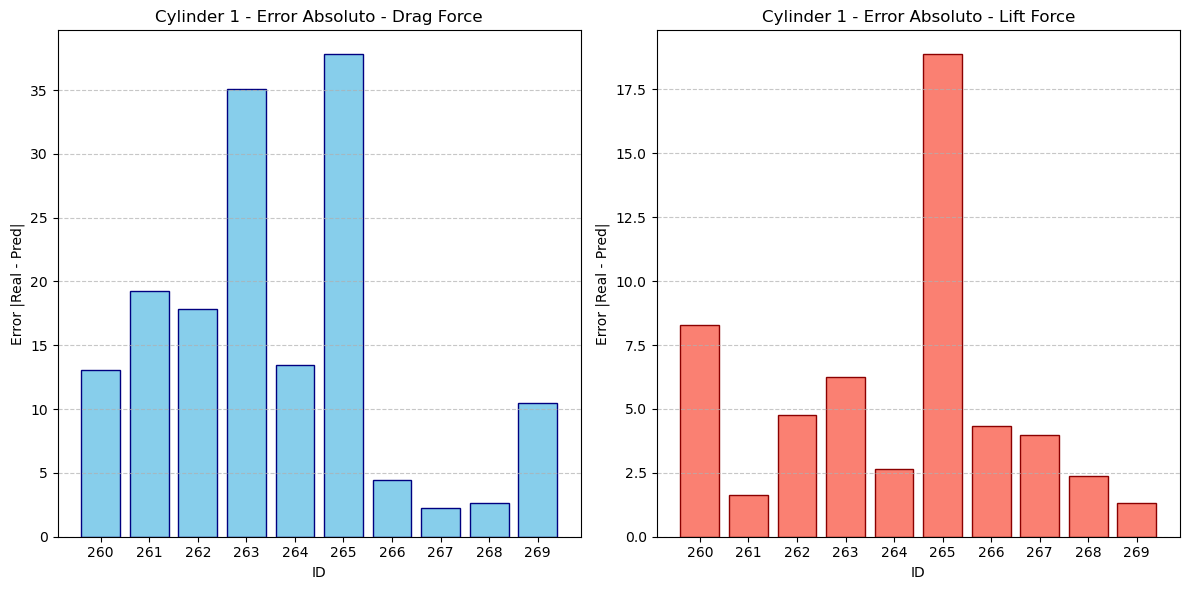

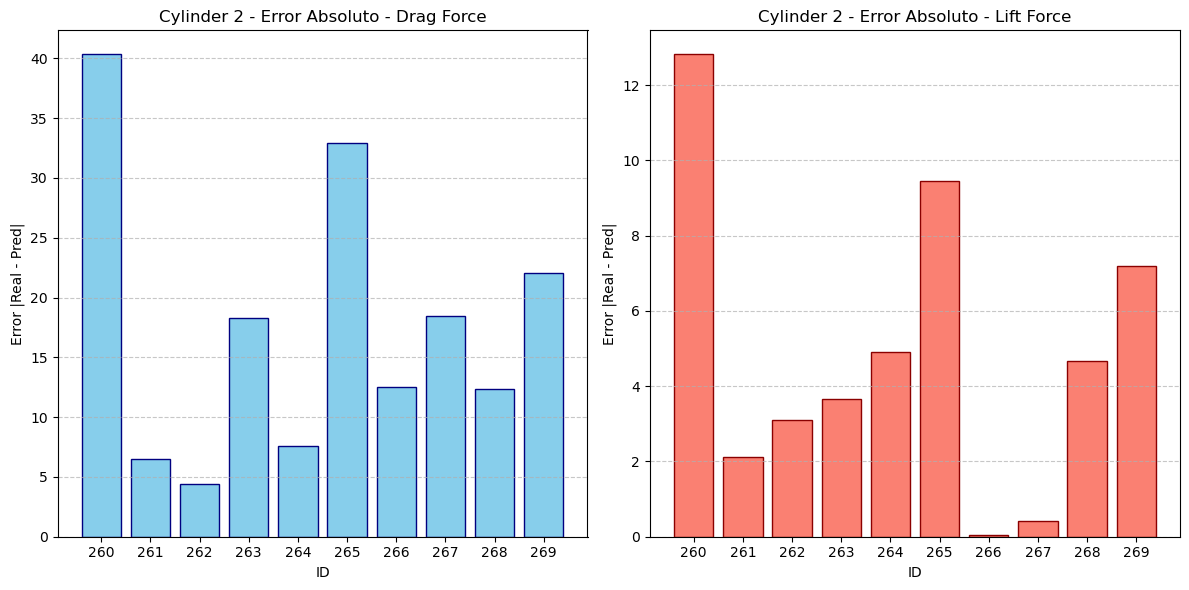

In [143]:
absolute_error(batch,'Drag_1','Lift_1',d1_final,l1_final,1)
absolute_error(batch,'Drag_2','Lift_2',d2_final,l2_final,2)
